# Intro

## Three types of layers in CNN

* Convolution: Learn filters (kernels) to create feature maps
* Pooling: Reduce dimensionality and increase receptive field size
* Fully connected: Prediction (categorical and/or continuous)

## Typical CNN architectural design

$$ \text{Convolution} \rightarrow \text{Pooling} \rightarrow \text{Convolution} \rightarrow \text{Pooling} \rightarrow \text{Fully Connected} $$

Discovered by many trials and errors to get the correct architecture.

With increasing depth:

* Image resolution (number of pixels) decreases
* Representation resolution (number of filters) increases

or

* Layers are smaller but wider

# CNN for MNIST

## Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchsummary import summary

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import numpy as np

## Data

In [ ]:
data = np.loadtxt(open('/content/sample_data/mnist_train_small.csv', 'rb'), delimiter = ',')

labels = data[:, 0]
data = data[:, 1:]

data = data / np.max(data)

labelsT = torch.tensor(labels).long()
dataT = torch.tensor(data).float()

# reshape the data
dataT = dataT.view(dataT.shape[0],1,28,28)
dataT.shape, labelsT.shape

(torch.Size([20000, 1, 28, 28]), torch.Size([20000]))

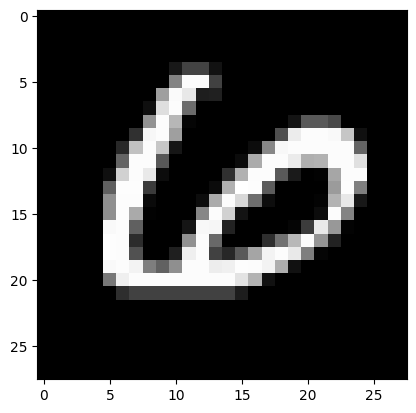

In [ ]:
plt.imshow(dataT[0].squeeze(), cmap = 'grey')
plt.show()

Unique Labels

In [ ]:
len(np.unique(labels))

10

## Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(dataT, labelsT, test_size = .8)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([4000, 1, 28, 28]),
 torch.Size([16000, 1, 28, 28]),
 torch.Size([4000]),
 torch.Size([16000]))

## Dataset and DataLoaders

In [ ]:
train_dataset, test_dataset = TensorDataset(X_train, y_train), TensorDataset(X_test, y_test)

batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, drop_last = True)
test_dataloader = DataLoader(test_dataset, batch_size = X_test.shape[0], shuffle = False)

## Model

In [244]:
def CreateModel(verbose):

  class CreateNet(nn.Module):
    def __init__(self, verbose):
      super().__init__()

      kernel_size = 5
      stride = 1
      padding = 1
      dim0 = 28 # dimension of input image - since we have square image (H = W) we can just leave dim0


      ### CONVOLUTION BLOCK ###
      self.conv1 = nn.Conv2d(in_channels = 1,
                            out_channels = 10,
                            kernel_size = kernel_size,
                            stride = stride,
                            padding = padding)

      # formula for dimension
      dim1 = torch.floor( torch.tensor((dim0 + 2 * padding - kernel_size)/stride )) + 1
      # maxpool change
      dim1 = dim1 // 2

      self.conv2 = nn.Conv2d(in_channels = 10,
                            out_channels = 20,
                            kernel_size = kernel_size,
                            stride = stride,
                            padding = padding)

      # formula for dimension
      dim2 = torch.floor( torch.tensor((dim1 + 2 * padding - kernel_size) / stride )) + 1
      # maxpool change
      dim2 = dim2 // 2

      ### FCN ###
      # we need to count input_shape (in_channels, dim, dim) = in_channels * dim * dim
      fcn_dim = 20 * int(dim2 * dim2)

      self.fc1 = nn.Linear(fcn_dim, 50)
      self.out = nn.Linear(50, 10)

      self.verbose = verbose

    def forward(self, x):
      # convolution -> maxpool -> relu
      x = F.relu(F.max_pool2d(self.conv1(x), 2))
      if self.verbose: print(f'Conv1/Pool1 shape: {x.shape}')

      x = F.relu(F.max_pool2d(self.conv2(x), 2))
      if self.verbose: print(f'Conv2/Pool2 shape: {x.shape}')

      # reshape data for fc layer
      n_units = x.numel() / x.shape[0]
      x = x.view(-1, int(n_units))
      if self.verbose: print(f'Vectorize: {x.shape}')

      # linear
      x = F.relu(self.fc1(x))
      if self.verbose: print(f'FC1 shape: {x.shape}')

      y = self.out(x)
      if self.verbose: print(f'Out shape: {y.shape}')

      return y

  net = CreateNet(verbose)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(net.parameters(), lr = 0.001)

  return net, loss_fn, optimizer

In [ ]:
net, loss_fn, optimizer = CreateModel(True)

X, y = next(iter(train_dataloader))
y_hat = net(X)

# check sizes of model outputs and target variable
print(' ')
print(y_hat.shape)
print(y.shape)

# now let's compute the loss
loss = loss_fn(y_hat, y)
print(' ')
print('Loss:')
print(loss)

/tmp/ipython-input-3526972396.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dim2 = torch.floor( torch.tensor((dim1 + 2 * padding - kernel_size) / stride )) + 1


Conv1/Pool1 shape: torch.Size([32, 10, 13, 13])
Conv2/Pool2 shape: torch.Size([32, 20, 5, 5])
Vectorize: torch.Size([32, 500])
FC1 shape: torch.Size([32, 50])
Out shape: torch.Size([32, 10])
 
torch.Size([32, 10])
torch.Size([32])
 
Loss:
tensor(2.3020, grad_fn=<NllLossBackward0>)


## Train Model

In [ ]:
# a function that trains the model
def ModelTrain(verbose):

  # number of epochs
  epochs = 10

  # model
  net, loss_fn, optimizer = CreateModel(verbose)

  # initialize losses
  losses = torch.zeros(epochs)
  train_acc = []
  test_acc = []

  # loop over epochs
  for epoch in range(epochs):
    net.train()
    batch_acc = []
    batch_loss = []

    for X,y in train_dataloader:

      # forward pass and loss
      y_hat = net(X)
      loss = loss_fn(y_hat, y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batch_loss.append(loss.item())

      # compute accuracy
      matches = (torch.argmax(y_hat, axis = 1) == y).float()
      accuracy = 100 * torch.mean(matches_numeric)
      batch_acc.append(accuracy)
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    train_acc.append(np.mean(batch_acc))

    # losses
    losses[epoch] = np.mean(batch_loss)

    # test accuracy
    net.eval()
    X, y = next(iter(test_dataloader))
    with torch.no_grad():
      y_hat = net(X)

    test_acc.append(
        100 * torch.mean(
            (torch.argmax(y_hat, axis = 1) == y).float()
        )
    )

    print(f'Epoch: {epoch} | Train Acc: {train_acc[-1]:.2f} | Test Acc: {test_acc[-1]:.2f}')
  # end epochs

  # output
  return train_acc, test_acc, losses, net

## Model Summary

Count the total number of parameters in the model

In [ ]:
summary(net, (1,28,28))

Conv1/Pool1 shape: torch.Size([2, 10, 13, 13])
Conv2/Pool2 shape: torch.Size([2, 20, 5, 5])
Vectorize: torch.Size([2, 500])
FC1 shape: torch.Size([2, 50])
Out shape: torch.Size([2, 10])
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 10, 26, 26]             260
            Conv2d-2           [-1, 20, 11, 11]           5,020
            Linear-3                   [-1, 50]          25,050
            Linear-4                   [-1, 10]             510
Total params: 30,840
Trainable params: 30,840
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.07
Params size (MB): 0.12
Estimated Total Size (MB): 0.19
----------------------------------------------------------------


## Run

In [ ]:
train_acc, test_acc, losses, net = ModelTrain(verbose = False)

/tmp/ipython-input-3526972396.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dim2 = torch.floor( torch.tensor((dim1 + 2 * padding - kernel_size) / stride )) + 1


Epoch: 0 | Train Acc: 65.72 | Test Acc: 86.48
Epoch: 1 | Train Acc: 90.65 | Test Acc: 91.94
Epoch: 2 | Train Acc: 93.88 | Test Acc: 94.31
Epoch: 3 | Train Acc: 95.22 | Test Acc: 95.07
Epoch: 4 | Train Acc: 96.28 | Test Acc: 95.49
Epoch: 5 | Train Acc: 96.65 | Test Acc: 95.24
Epoch: 6 | Train Acc: 97.50 | Test Acc: 96.07
Epoch: 7 | Train Acc: 97.95 | Test Acc: 96.10
Epoch: 8 | Train Acc: 98.10 | Test Acc: 95.99
Epoch: 9 | Train Acc: 98.40 | Test Acc: 96.78


## Plot

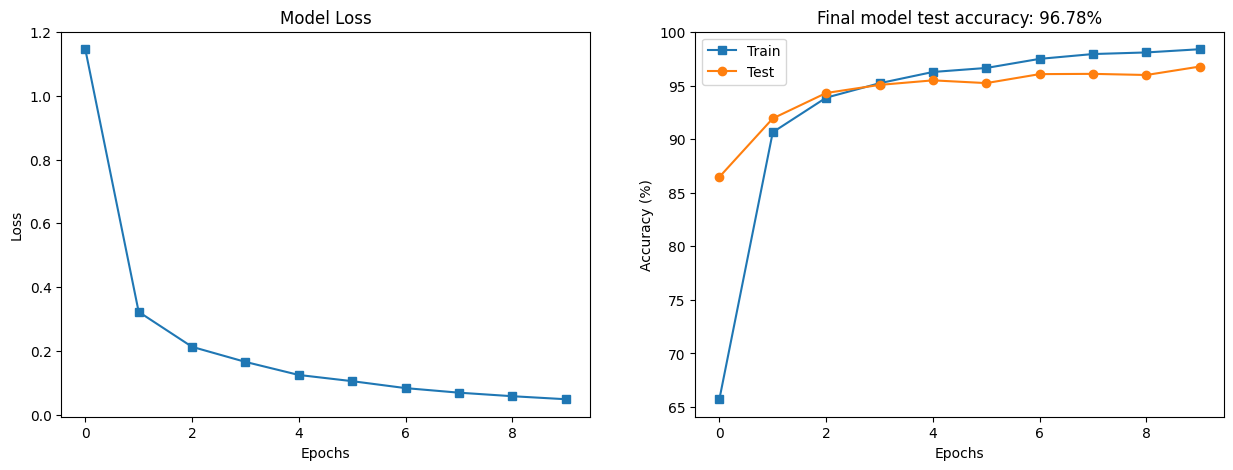

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(15,5))

ax[0].plot(losses, 's-')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model Loss')

ax[1].plot(train_acc, 's-', label = 'Train')
ax[1].plot(test_acc, 'o-', label = 'Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {test_acc[-1]:.2f}%')
ax[1].legend()

plt.show()

# CNN for Shifted MNIST

## Imports

In [273]:
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
from sklearn.model_selection import train_test_split

## Data

In [274]:
data = np.loadtxt(open('/content/sample_data/mnist_train_small.csv', 'rb'), delimiter = ',')

labels = data[:,0]
data = data[:, 1:]

labels = torch.tensor(labels, dtype = torch.long)
data = torch.tensor(data, dtype = torch.float)
data_norm = data / torch.max(data)

labels.shape, data_norm.shape

(torch.Size([20000]), torch.Size([20000, 784]))

In [275]:
data = data_norm.reshape(data_norm.shape[0], 1, 28, 28)
data.shape

torch.Size([20000, 1, 28, 28])

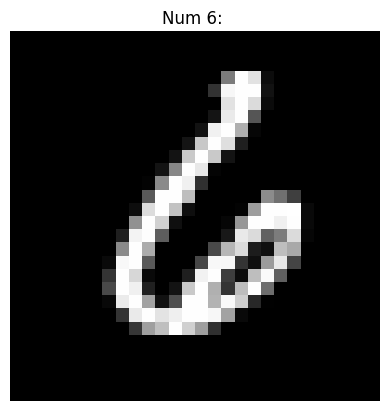

In [276]:
rand_row = np.random.randint(data.shape[0])
img = data[rand_row].squeeze()
num = labels[rand_row]

plt.imshow(img, cmap = 'grey')
plt.title('Num %d: '%num)
plt.axis(False)
plt.show()

## Train Test Split

In [277]:
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, test_size = .2)

## Dataset and DataLoader

In [278]:
train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = test_data.shape[0])

In [279]:
train_dataloader.dataset.tensors[0].shape

torch.Size([16000, 1, 28, 28])

## Image Shifts

### Shift the images by a few pixels

In [280]:
# tmp = train_dataloader.dataset.tensors[0][2,:]
# tmp = tmp.reshape(28,28)

# shifted_tmp = torch.roll(tmp, shifts = 10, dims = 0)
# fig, ax = plt.subplots(1,2,figsize = (10,5))
# ax[0].imshow(tmp, cmap= 'grey')
# ax[1].imshow(shifted_tmp, cmap = 'grey')
# plt.show()

### Roll Every Image

Before augmentation

In [281]:
# train_dataloader.dataset.tensors[0].shape

In [282]:
# X, y = train_dataloader.dataset.tensors  # X: (N,1,28,28)

# aug_X = []
# aug_y = []

# for i in range(X.shape[0]):
#     shift = torch.randint(-11, 10, (1,)).item()
#     aug_X.append(torch.roll(X[i], shift, dims=2))
#     aug_y.append(y[i])

# X_new = torch.cat([X, torch.stack(aug_X)], dim=0)
# y_new = torch.cat([y, torch.stack(aug_y)], dim=0)

# train_dataloader.dataset.tensors = (X_new, y_new)

After augmentation

In [283]:
# train_dataloader.dataset.tensors[0].shape

## Image Shift

### Single Image

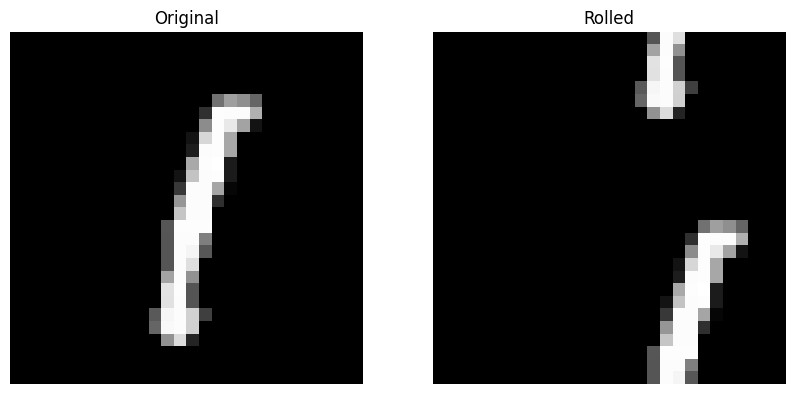

In [284]:
rand_row = np.random.randint(len(train_dataloader))
rand_img = train_dataloader.dataset.tensors[0][rand_row].squeeze()

rolled_img = torch.roll(rand_img, shifts = (10,5), dims = (0,1))

fig, axs = plt.subplots(1,2,figsize = (10,5))

axs[0].imshow(rand_img, cmap = 'grey')
axs[0].axis('off')
axs[0].set_title('Original')

axs[1].imshow(rolled_img, cmap = 'gray')
axs[1].axis('off')
axs[1].set_title('Rolled')

plt.show()

### Roll Every Image in Train Set

In [285]:
X, y = train_dataloader.dataset.tensors

X_aug, y_aug = torch.zeros_like(X), torch.zeros_like(y)

for i in range(len(X)):
  temp_X = X[i].squeeze()

  shifts = tuple(torch.randint(-10, 10, size = (2,)).tolist())
  rolled_img = torch.roll(temp_X, shifts = shifts, dims = (0, 1))
  X_aug[i] = rolled_img.unsqueeze(0)
  y_aug[i] = y[i]

Check if Augmentation went well

In [286]:
X_aug.shape[0]

16000

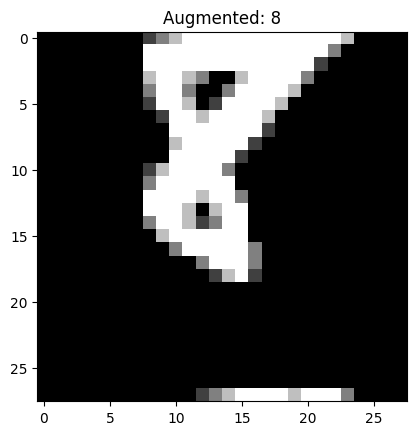

In [287]:
rand_img = np.random.randint(X_aug.shape[0])

plt.imshow(X_aug[rand_img].squeeze(), cmap = 'grey')
plt.title(f'Augmented: {y_aug[rand_img]}')
plt.show()

Concat Original and Aug

In [288]:
X_new = torch.cat((X, X_aug), axis = 0)
y_new = torch.cat((y, y_aug), axis = 0)

train_dataloader.dataset.tensors = (X_new, y_new)

In [289]:
train_dataloader.dataset.tensors[0].shape

torch.Size([32000, 1, 28, 28])

In [290]:
train_dataloader.dataset.tensors[1].shape

torch.Size([32000])

Eventually we've artificially doubled train_dataloader.

## Train Model

In [291]:
def ModelTrain(epochs, verbose):
  net, loss_fn, optimizer = CreateModel(verbose)

  losses = torch.zeros(epochs)
  train_accs = []
  test_accs = []


  for epoch in range(epochs):
    net.train()

    batch_acc = []
    batch_loss = []


    for X, y in train_dataloader:

      y_hat = net(X)
      loss = loss_fn(y_hat, y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batch_loss.append(loss.item())

      # compute accuracy
      matches = torch.argmax(y_hat, axis = 1) == y
      matches_numeric = matches.float()
      accuracy_pct = 100 * torch.mean(matches_numeric)
      batch_acc.append(accuracy_pct)
    # end of batch loop

    #training accuracy
    train_acc = np.mean(batch_acc)
    train_accs.append(train_acc)

    # and get  avg losses
    losses[epoch] = np.mean(batch_loss)

    # test accuracy
    net.eval()
    X, y = next(iter(test_dataloader))
    with torch.no_grad(): # deactivates autograd
      y_hat = net(X)

    test_acc = 100 * torch.mean((torch.argmax(y_hat, axis = 1) == y).float())
    test_accs.append(test_acc)
  # end epochs

    print(f'Epoch: {epoch} | Train Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f} | Loss: {losses[epoch]:.2f}')

  return train_accs, test_accs, losses

## Run

In [292]:
train_accs, test_accs, losses = ModelTrain(epochs = 10, verbose = False)

/tmp/ipython-input-407162436.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dim2 = torch.floor( torch.tensor((dim1 + 2 * padding - kernel_size) / stride )) + 1


Epoch: 0 | Train Acc: 66.03 | Test Acc: 94.75 | Loss: 1.02
Epoch: 1 | Train Acc: 85.20 | Test Acc: 95.70 | Loss: 0.45
Epoch: 2 | Train Acc: 89.48 | Test Acc: 95.85 | Loss: 0.33
Epoch: 3 | Train Acc: 91.07 | Test Acc: 96.57 | Loss: 0.28
Epoch: 4 | Train Acc: 92.76 | Test Acc: 96.85 | Loss: 0.23
Epoch: 5 | Train Acc: 93.41 | Test Acc: 97.07 | Loss: 0.20
Epoch: 6 | Train Acc: 94.10 | Test Acc: 97.15 | Loss: 0.19
Epoch: 7 | Train Acc: 94.85 | Test Acc: 97.05 | Loss: 0.16
Epoch: 8 | Train Acc: 95.28 | Test Acc: 96.70 | Loss: 0.15
Epoch: 9 | Train Acc: 95.68 | Test Acc: 97.50 | Loss: 0.14


## Plot

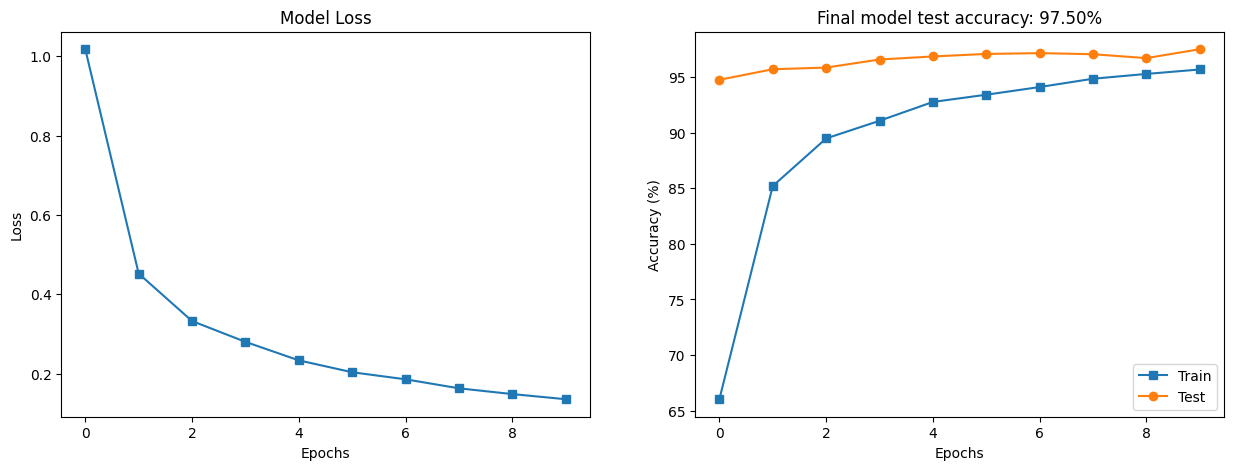

In [293]:
fig, ax = plt.subplots(1,2,figsize=(15,5))

ax[0].plot(losses, 's-')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model Loss')

ax[1].plot(train_accs, 's-', label = 'Train')
ax[1].plot(test_accs, 'o-', label = 'Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {test_accs[-1]:.2f}%')
ax[1].legend()

plt.show()

We were able to achieve accuracy better by around 1% by augmenting data with rolled images which is typical range of accuracy improvement after data augmentation.